# SVM for classification

Load IRIS dataset, check its contents:


In [2]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [3]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [4]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

1.0

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



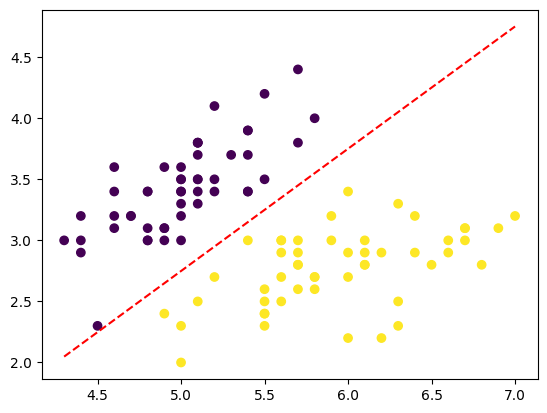

In [5]:
import matplotlib.pyplot as plt
import numpy as np

X = iris.data[:, :2]
y = iris.target

X, y = X[y < 2], y[y < 2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)

plt.scatter(X[:,0],X[:,1], c=y)


W = SVMmodel.coef_
b = SVMmodel.intercept_

x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
y_vals = -(W[0,0] * x_vals +b[0]) / W[0,1]

plt.plot(x_vals, y_vals, 'r--')

plt.show()





# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

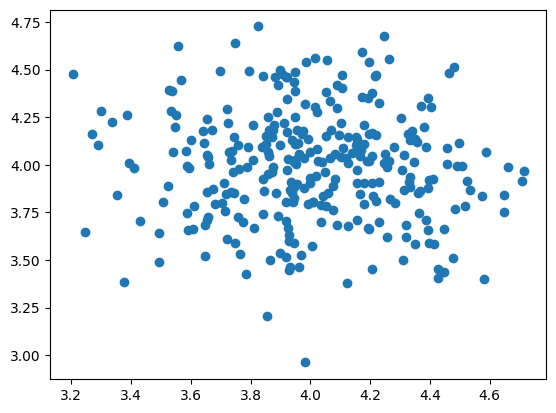

In [6]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

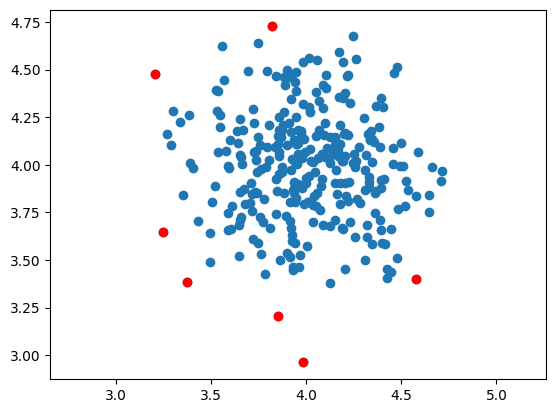

In [7]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

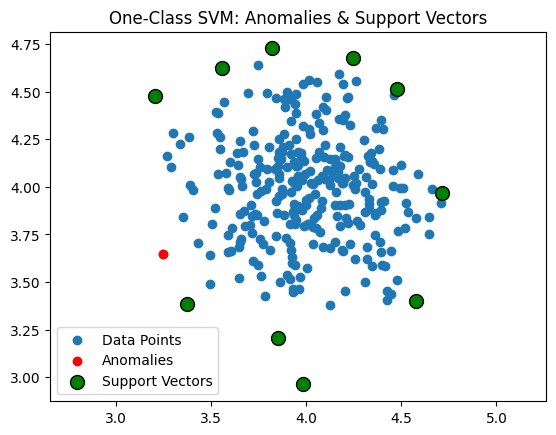

In [8]:
# Get support vectors
support_vectors = SVMmodelOne.support_vectors_

# Plot all data points
plt.scatter(x[:, 0], x[:, 1], label='Data Points', zorder=1)

# Plot anomalies
plt.scatter(values[:, 0], values[:, 1], color='red', label='Anomalies', zorder=2)

# Plot support vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            color='green', edgecolors='black', s=100,
            label='Support Vectors', zorder=3)

plt.axis('equal')
plt.legend()
plt.title('One-Class SVM: Anomalies & Support Vectors')
plt.show()

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.987833799021839


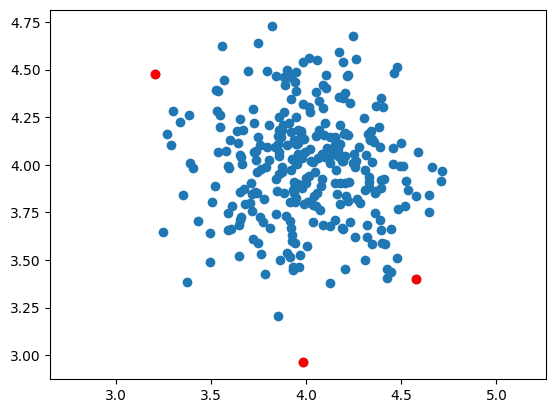

In [9]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.01)
print(thresh)
index = where(scores<=thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()